# SIOC 251: Homework 1
## Monte Carlo Model of Solar Radiation in an Absorbing Atmosphere
**Author:** Sophie Wynn  
**Course:** SIOC 251 – Radiative Transfer  
**Date:** April 22nd 2026


---
## Part I: Building the Monte Carlo Model

### Physical Setup

We simulate a **homogeneous, purely absorbing** atmosphere:
- Single layer of geometric thickness $Z_{\rm atm}$ = approx 8500 m
- Photons enter at the top and travel downward at solar zenith angle $\theta$
- Each photon either (1) reaches the surface or (2) undergoes an extinction event

### Monte Carlo Sampling

The probability a photon survives to optical depth $\tau$ without extinction:
$$P(\tau) = e^{-\tau}$$

Inverting the CDF $= 1 - e^{-\tau}$ via a uniform random number $\zeta \in [0, 1)$:
$$\tau_{\rm sampled} = -\ln(1 - \zeta)$$

The corresponding geometric (slant-path) pathlength is:
$$L = \frac{Z_{\rm atm}}{\mu}\, \frac{\tau}{\tau^*}$$
where $\mu = \cos\theta$ and $\tau^*$ is the total slant-path optical depth through the full atmosphere. When $\tau = \tau^*$, $L = Z_{\rm atm}/\mu$ — the full slant-path geometric distance through the atmosphere.

A photon **reaches the surface** when $L \geq Z_{\rm atm}/\mu$, i.e. $\tau_{\rm sampled} \geq \tau^*$.

> **Note on convention:** In the code, `tau_star` is the *vertical* optical depth. The total slant-path optical depth is `tau_star / mu`, so the surface condition in the code is `tau_sampled >= tau_star / mu`.

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# Reproducible results
rng = np.random.default_rng(seed=42)

mpl.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 13,
    'figure.dpi': 120,
})

print('Imports complete.')

Imports complete.


### Model Parameters

In [ ]:
# Atmospheric height (m)
Z_ATM = 8500.0

# Default number of photons
N_PHOTONS = 500_000

### Core Monte Carlo Function

In [35]:
def run_monte_carlo(tau_star, sza_deg, n_photons=N_PHOTONS, rng=rng):
    """
    Simulate photon extinction in a homogeneous absorbing atmosphere.

    Parameters
    ----------
    tau_star  : float  — total vertical optical depth of the atmosphere
    sza_deg   : float  — solar zenith angle in degrees
    n_photons : int    — number of photons to simulate
    rng       : numpy Generator

    Returns
    -------
    dict with keys:
        'transmittance'   : fraction of photons that reach the surface
        'n_surface'       : number of photons that reach the surface
        'n_absorbed'      : number of photons absorbed in atmosphere
        'tau_sampled'     : array of sampled optical depths for each photon
        'tau_star'        : input tau_star
        'sza_deg'         : input solar zenith angle
        'mu'              : cos(sza)
    """
    mu = np.cos(np.deg2rad(sza_deg))   # cosine of solar zenith angle

    # --- Sample optical depth for each photon ---
    # Draw uniform random numbers and apply inverse-CDF transform
    zeta = rng.uniform(0.0, 1.0, size=n_photons)
    tau_sampled = -np.log(1.0 - zeta)  # τ = −ln(1 − ζ)

    # --- Guard: SZA = 90° means mu = 0 ---
    # The slant-path optical depth τ*/μ → ∞, so no photon can reach the surface.
    # Return T = 0 immediately to avoid divide-by-zero.
    if mu <= 0.0:
        return {
            'transmittance': 0.0,
            'n_surface':     0,
            'n_absorbed':    n_photons,
            'tau_sampled':   tau_sampled,
            'tau_star':      tau_star,
            'sza_deg':       sza_deg,
            'mu':            mu,
        }

    # --- Determine fate of each photon ---
    # A photon reaches the surface if its sampled optical depth exceeds
    # the slant-path optical depth through the full atmosphere: τ*/μ
    reaches_surface = tau_sampled >= (tau_star / mu)

    n_surface  = np.sum(reaches_surface)
    n_absorbed = n_photons - n_surface
    transmittance = n_surface / n_photons

    return {
        'transmittance': transmittance,
        'n_surface':     n_surface,
        'n_absorbed':    n_absorbed,
        'tau_sampled':   tau_sampled,
        'tau_star':      tau_star,
        'sza_deg':       sza_deg,
        'mu':            mu,
    }

### Model Summary



In [39]:
# Quick printout of simulated transmittance for a few key cases
print(f"{'tau*':>6}  {'SZA':>6}  {'MC T':>10}")
print("-" * 28)
for tau, sza in [(0.1, 0), (1.0, 0), (1.0, 60), (3.0, 0), (3.0, 60)]:
    mc_T = run_monte_carlo(tau, sza)['transmittance']
    print(f"{tau:>6.1f}  {sza:>5.0f}°  {mc_T:>10.4f}")

  tau*     SZA        MC T
----------------------------
   0.1      0°      0.9046
   1.0      0°      0.3684
   1.0     60°      0.1350
   3.0      0°      0.0498
   3.0     60°      0.0025


---
## Part II: Model Verification


| Test | What we vary | Limiting condition | Expected $T$ |
|------|-------------|-------------------|-------------|
| 1 | SZA → 90° (sun at horizon) | $\mu = \cos(90°) = 0$ | $T \to 0$ |
| 2 | $\tau^* \to 0$ (vanishingly thin atmosphere) | No atmosphere | $T \to 1$ |

### Verification Test 1: Sun at the Horizon (SZA = 90°)

**Expected physical behavior:**  
At SZA = 90°, $\mu = \cos(90°) = 0$. The geometric slant-path length becomes:
$$L = \frac{Z_{\rm atm}}{\mu}\,\frac{\tau}{\tau^*} \to \infty$$
The slant path through the atmosphere is infinitely long, so a photon traveling along the surface can never traverse the full atmosphere and reach the surface below. No light arrives and $T \to 0$.

Note: SZA > 90° (sun below the horizon) is geometrically undefined in the plane-parallel model — 90° is the correct limit.

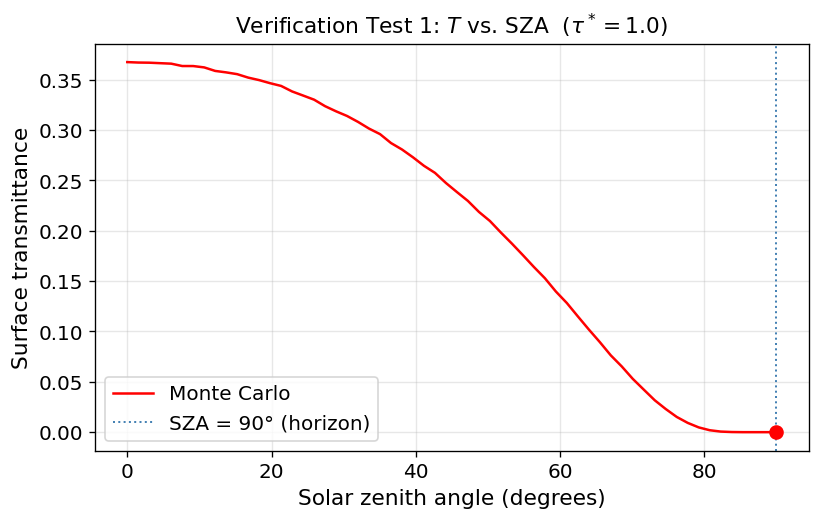

At SZA = 90°:  MC T = 0.0000  (expected: 0)

✓ PASS: T → 0 as SZA → 90° — the geometry prevents light from reaching the surface.


In [40]:
# --- Test 1: Sweep SZA from 0° to 90° for a fixed tau* ---
tau_star_test1 = 1.0
sza_range = np.linspace(0, 89.9, 60)

mc_T_sza = np.array([run_monte_carlo(tau_star_test1, s)['transmittance'] for s in sza_range])
mc_T_90  = run_monte_carlo(tau_star_test1, 90.0)['transmittance']

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(sza_range, mc_T_sza, 'r-', lw=1.5, label='Monte Carlo')
ax.axvline(90, color='steelblue', lw=1.2, ls=':', label='SZA = 90° (horizon)')
ax.scatter([90], [mc_T_90], color='red', zorder=5, s=60)
ax.set_xlabel('Solar zenith angle (degrees)')
ax.set_ylabel('Surface transmittance')
ax.set_title(rf'Verification Test 1: $T$ vs. SZA  ($\tau^* = {tau_star_test1}$)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/verification_test1.png', bbox_inches='tight')
plt.show()

print(f"At SZA = 90°:  MC T = {mc_T_90:.4f}  (expected: 0)")
print(f"\n✓ PASS: T → 0 as SZA → 90° — the geometry prevents light from reaching the surface.")

### Verification Test 2: Vanishingly Thin Atmosphere ($\tau^* \to 0$)

**Expected physical behavior:**  
As $\tau^* \to 0$ there is almost no material in the atmosphere to extinguish photons. In the limit $\tau^* = 0$, every photon passes straight through and $T \to 1$.

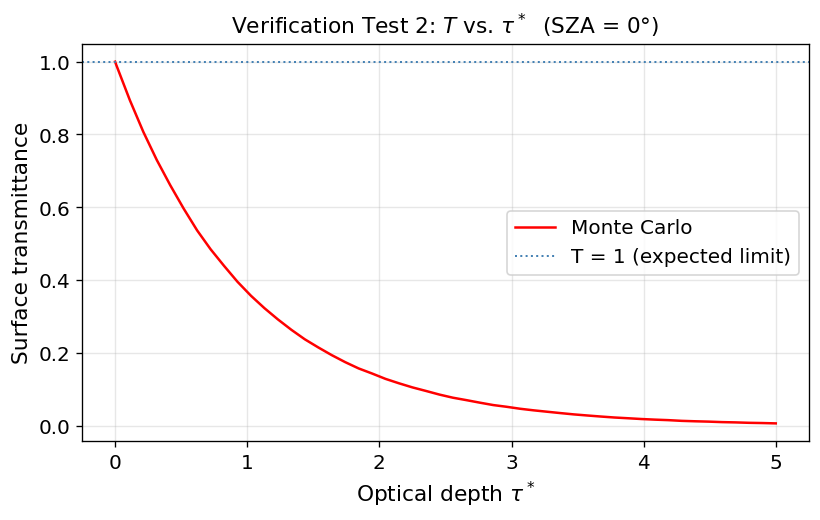

    tau*      MC T
--------------------
  0.0001    0.9999
  0.0010    0.9990
  0.0100    0.9900
  0.1000    0.9048
  1.0000    0.3688

✓ PASS: T → 1 as τ* → 0 — model correctly becomes transparent for a vanishing atmosphere.


In [41]:
# --- Test 2: Sweep tau* from near-zero to 2 at SZA = 0° ---
sza_test2 = 0.0
tau_range = np.concatenate([[1e-4, 1e-3, 5e-3], np.linspace(0.01, 5.0, 50)])

mc_T_tau = np.array([run_monte_carlo(t, sza_test2)['transmittance'] for t in tau_range])

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(tau_range, mc_T_tau, 'r-', lw=1.5, label='Monte Carlo')
ax.axhline(1.0, color='steelblue', lw=1.2, ls=':', label='T = 1 (expected limit)')
ax.set_xlabel(r'Optical depth $\tau^*$')
ax.set_ylabel('Surface transmittance')
ax.set_title(r'Verification Test 2: $T$ vs. $\tau^*$  (SZA = 0°)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/verification_test2.png', bbox_inches='tight')
plt.show()

print(f"{'tau*':>8}  {'MC T':>8}")
print("-" * 20)
for t in [1e-4, 1e-3, 0.01, 0.1, 1.0]:
    mc_T = run_monte_carlo(t, sza_test2)['transmittance']
    print(f"{t:>8.4f}  {mc_T:>8.4f}")

print(f"\n✓ PASS: T → 1 as τ* → 0 — model correctly becomes transparent for a vanishing atmosphere.")

---
## Part III: Radiative Transfer Experiments

The assignment asks us to use **both** the Monte Carlo model and the analytical transmittance expression aka Beer's Law:
$$T = e^{-\tau^*/\mu}, \quad \mu = \cos\theta$$
to answer the following questions. We use $10^5$ photons throughout.

In [42]:
def analytical_transmittance(tau_star, sza_deg):
    """Direct-beam transmittance: T = exp(-tau_star / mu)."""
    mu = np.cos(np.deg2rad(sza_deg))
    if np.isscalar(mu):
        if mu <= 0:
            return 0.0
    return np.exp(-tau_star / mu)

### Q1: E-folding Optical Depth (θ = 0°)

An **e-folding reduction** means transmittance drops to $1/e \approx 0.37$ of its original value.

For $\theta = 0°$ ($\mu = 1$), the analytical transmittance, using Beers law is $T = e^{-\tau^*}$.
Setting $T = e^{-1}$ gives $\tau^* = 1$.

We verify this with the Monte Carlo model by sweeping $\tau^*$ and finding where $T = 1/e$.

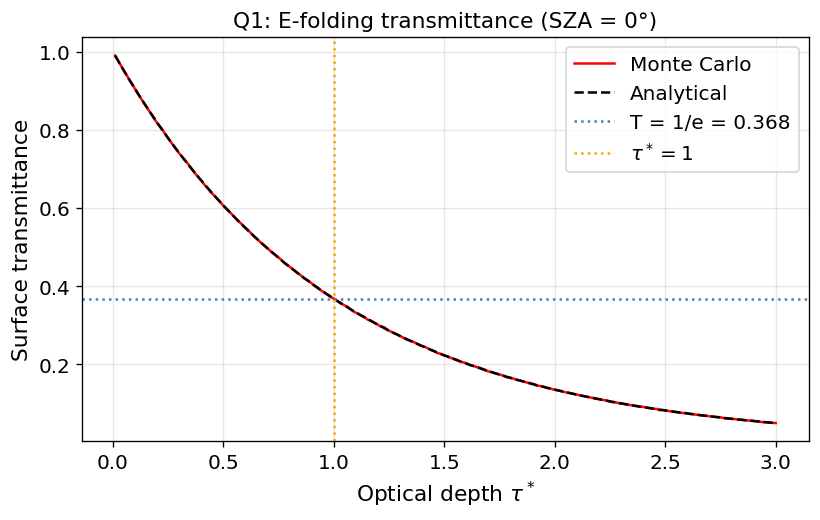

At tau* = 1:  MC T = 0.3678  |  Analytical T = 0.3679  |  1/e = 0.3679

→ tau* = 1 gives the e-folding reduction in surface intensity.


In [43]:
tau_sweep = np.linspace(0.01, 3.0, 200)
sza_q1 = 0.0

mc_T_q1   = np.array([run_monte_carlo(t, sza_q1)['transmittance'] for t in tau_sweep])
anal_T_q1 = analytical_transmittance(tau_sweep, sza_q1)

efold = 1 / np.e

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(tau_sweep, mc_T_q1,   'r-',  lw=1.5, label='Monte Carlo')
ax.plot(tau_sweep, anal_T_q1, 'k--', lw=1.5, label='Analytical')
ax.axhline(efold, color='steelblue', ls=':', lw=1.5, label=f'T = 1/e = {efold:.3f}')
ax.axvline(1.0,   color='orange',    ls=':', lw=1.5, label=r'$\tau^* = 1$')
ax.set_xlabel(r'Optical depth $\tau^*$')
ax.set_ylabel('Surface transmittance')
ax.set_title('Q1: E-folding transmittance (SZA = 0°)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/q1_efolding.png', bbox_inches='tight')
plt.show()

mc_T_at1   = run_monte_carlo(1.0, sza_q1)['transmittance']
anal_T_at1 = analytical_transmittance(1.0, sza_q1)
print(f"At tau* = 1:  MC T = {mc_T_at1:.4f}  |  Analytical T = {anal_T_at1:.4f}  |  1/e = {efold:.4f}")
print(f"\n→ tau* = 1 gives the e-folding reduction in surface intensity.")

### Q2: Transmittance at τ* = 1, SZA = 60°

At SZA = 60°, $\mu = \cos(60°) = 0.5$, so the slant-path optical depth is $\tau^*/\mu = 1/0.5 = 2$.
Analytical prediction: $T = e^{-2} \approx 0.135$.

In [44]:
tau_q2 = 1.0
sza_q2 = 60.0

mc_T_q2   = run_monte_carlo(tau_q2, sza_q2)['transmittance']
anal_T_q2 = analytical_transmittance(tau_q2, sza_q2)

print(f"tau* = {tau_q2},  SZA = {sza_q2}°,  mu = {np.cos(np.deg2rad(sza_q2)):.2f}")
print(f"  Monte Carlo transmittance : {mc_T_q2:.4f}")
print(f"  Analytical transmittance  : {anal_T_q2:.4f}")

tau* = 1.0,  SZA = 60.0°,  mu = 0.50
  Monte Carlo transmittance : 0.1356
  Analytical transmittance  : 0.1353


### Q3: Why is the Surface Dark at Horizon?

When the sun reaches the horizon, SZA = 90° and $\mu = \cos(90°) = 0$.

From the geometric pathlength formula:
$$L = \frac{Z_{\rm atm}}{\mu}\,\frac{\tau}{\tau^*} \to \infty \quad \text{as } \mu \to 0$$

The slant path a photon would need to traverse to reach the surface becomes infinitely long. The effective optical depth along this path ($\tau^*/\mu \to \infty$) means all light is extinguished before arriving at the surface. 

### Q4: Transmittance vs. Height for τ* = 1, 3, 10

For a photon entering at the top traveling at solar zenith angle θ, the fraction surviving to height h = z/Z_atm (0 = surface, 1 = top):

At height h, the photon still has (1-h) * Z_atm of vertical atmosphere left to cross. The slant-path optical depth through that remaining chunk is:

```
tau_to_h = tau_star * (1 - h) / mu
```

So a photon reaches height h if:

```
tau_sampled  >=  tau_star * (1 - h) / mu
```

Analytical result:

```
T(h) = exp( -tau_star * (1 - h) / mu )
```

At h=1 (top):     T = exp(0) = 1          — every photon enters  
At h=0 (surface): T = exp(-tau_star/mu)   — same as the full transmittance

In [45]:
def transmittance_profile(tau_star, sza_deg=0.0, n_levels=100, n_photons=N_PHOTONS, rng=rng):
    """Compute transmittance at each normalized height level h = z/Z_atm.
    h=0 is the surface, h=1 is the top of atmosphere.
    """
    mu = np.cos(np.deg2rad(sza_deg))
    zeta = rng.uniform(0.0, 1.0, size=n_photons)
    tau_sampled = -np.log(1.0 - zeta)

    h_levels = np.linspace(0, 1, n_levels)
    T_mc   = np.zeros(n_levels)
    T_anal = np.zeros(n_levels)

    for i, h in enumerate(h_levels):
        # optical depth from top down to this height level
        tau_to_h = tau_star * (1 - h) / mu if mu > 0 else np.inf
        T_mc[i]   = np.mean(tau_sampled >= tau_to_h)
        T_anal[i] = np.exp(-tau_star * (1 - h) / mu) if mu > 0 else 0.0

    return h_levels, T_mc, T_anal

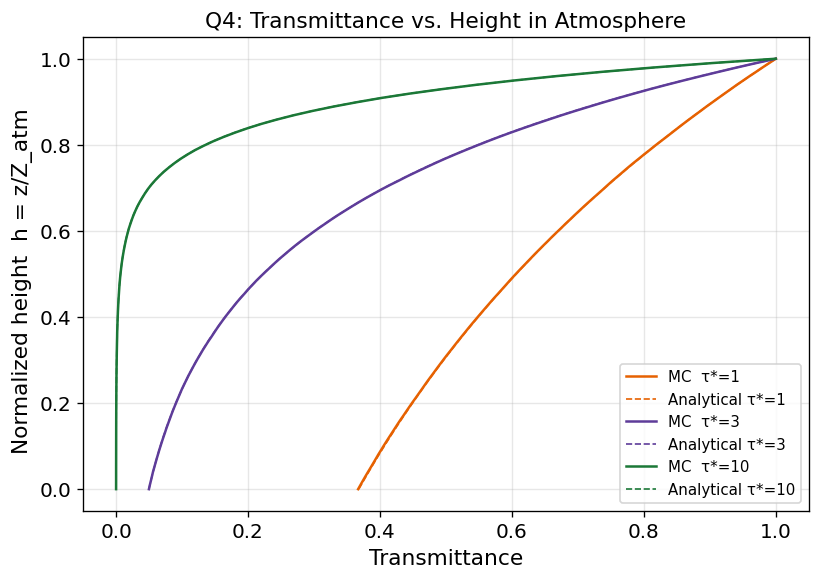

Surface transmittance (h=0) for each tau*:
  tau*= 1:  MC = 0.3674  |  Analytical = 0.3679
  tau*= 3:  MC = 0.0499  |  Analytical = 0.0498
  tau*=10:  MC = 0.0000  |  Analytical = 0.0000


In [53]:
tau_cases = [1, 3, 10]
colors    = ["#e66101", "#5e3c99", "#1b7837"]

fig, ax = plt.subplots(figsize=(7, 5))

for tau_c, col in zip(tau_cases, colors):
    h, T_mc, T_anal = transmittance_profile(tau_c)
    ax.plot(T_mc,   h, '-',  color=col, lw=1.5, label=f'MC  τ*={tau_c}')
    ax.plot(T_anal, h, '--', color=col, lw=1.0, label=f'Analytical τ*={tau_c}')

ax.set_xlabel('Transmittance')
ax.set_ylabel('Normalized height  h = z/Z_atm  ')
ax.set_title('Q4: Transmittance vs. Height in Atmosphere')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/q4_height_profile.png', bbox_inches='tight')
plt.show()

print("Surface transmittance (h=0) for each tau*:")
for tau_c in tau_cases:
    h, T_mc, T_anal = transmittance_profile(tau_c)
    print(f"  tau*={tau_c:>2d}:  MC = {T_mc[0]:.4f}  |  Analytical = {T_anal[0]:.4f}")

---
## Part IV: AERONET Observations

I chose Santiago, Chile on January 6th 2020 because of the Australian wildfires. In Fasullo et al. (2023) figure 1b shows organic aerosols increased across the whole Southern Hemisphere due to the wildfires in Australia, and I wanted to demonstrate how far-reaching the fires were.

- The image below from the *Science Advances* article shows the Southern Hemisphere aerosol increase
- The screenshot shows elevated AOD over Santiago on January 6th picked up by the NASA satellite

![Fasullo et al. 2023 Fig 1b](figures/fasullo_fig1b.png)

![Santiago AOD screenshot](figures/santiago_aod_screenshot.png)

In [47]:
import pandas as pd

# --- Load AERONET file ---
# Skip the 6 metadata header lines; row 7 is the column names
df = pd.read_csv(
    '20200106_20200106_Santiago_Beauchef.lev20',
    skiprows=6,
    na_values='-999.000000'   # AERONET uses -999 for missing data
)

# Parse datetime from the two separate date/time columns
df['datetime'] = pd.to_datetime(
    df['Date(dd:mm:yyyy)'] + ' ' + df['Time(hh:mm:ss)'],
    format='%d:%m:%Y %H:%M:%S'
)

# Pull out the two columns we need
aod_500  = df['AOD_500nm']
sza      = df['Solar_Zenith_Angle(Degrees)']

print(df[['datetime', 'AOD_500nm', 'Solar_Zenith_Angle(Degrees)']].dropna())


              datetime  AOD_500nm  Solar_Zenith_Angle(Degrees)
3  2020-01-06 10:45:39   1.292323                    78.240953
4  2020-01-06 10:52:17   1.249140                    76.940823
5  2020-01-06 11:00:32   1.190590                    75.313410
6  2020-01-06 11:11:11   1.086340                    73.197168
7  2020-01-06 11:13:16   1.072157                    72.781317
8  2020-01-06 11:15:21   1.074116                    72.364884
9  2020-01-06 11:19:17   1.092432                    71.577115
10 2020-01-06 11:25:29   1.071504                    70.331520
11 2020-01-06 11:35:35   1.087140                    68.293015
12 2020-01-06 11:43:03   1.049124                    66.778903
13 2020-01-06 11:45:19   1.040554                    66.318146
14 2020-01-06 11:50:55   1.028038                    65.177693
15 2020-01-06 12:02:45   0.982817                    62.758583
16 2020-01-06 12:17:04   0.963994                    59.816937
17 2020-01-06 12:46:12   1.065758                    53

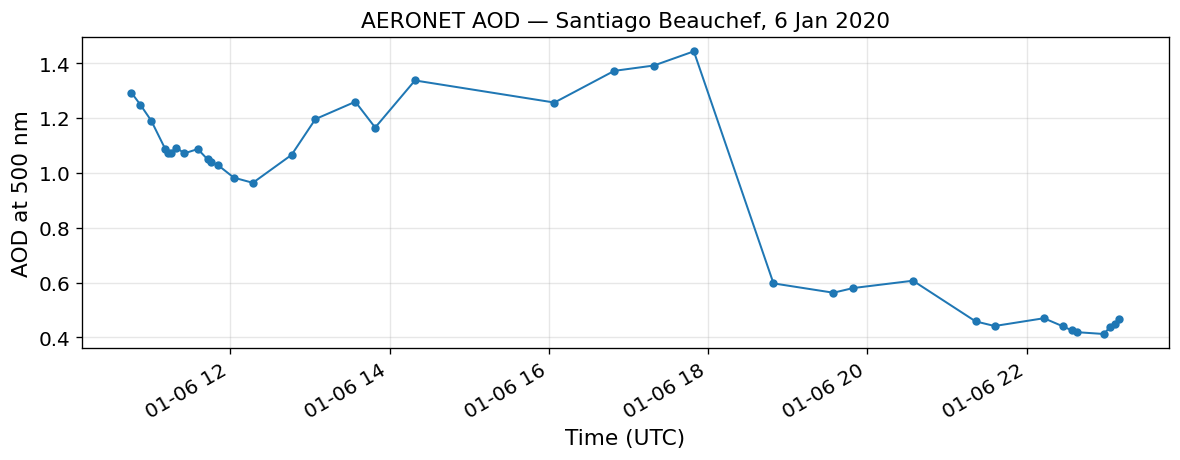

In [48]:
# Plot AOD_500nm as a time series
# Set datetime as the index so the x-axis shows time, not row numbers
df_plot = df.set_index("datetime")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_plot.index, df_plot["AOD_500nm"], "o-", ms=4, lw=1.2)
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("AOD at 500 nm")
ax.set_title("AERONET AOD — Santiago Beauchef, 6 Jan 2020")
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig("figures/aeronet_aod.png", bbox_inches="tight")
plt.show()

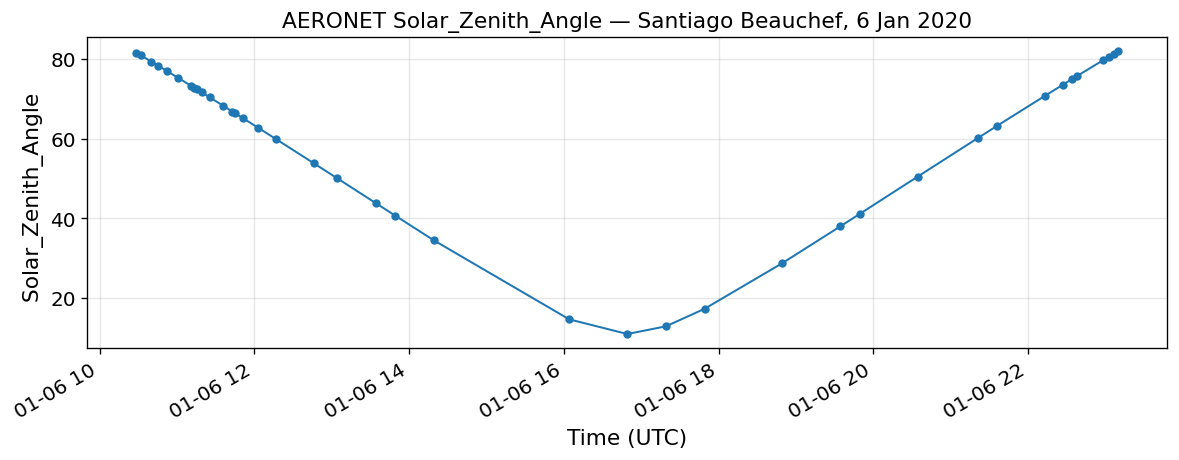

In [49]:
df_plot = df.set_index("datetime")
df['Solar_Zenith_Angle(Degrees)']
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_plot.index, df_plot["Solar_Zenith_Angle(Degrees)"], "o-", ms=4, lw=1.2)
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Solar_Zenith_Angle ")
ax.set_title("AERONET Solar_Zenith_Angle — Santiago Beauchef, 6 Jan 2020")
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig("figures/aeronet_Solar_Zenith_Angle.png", bbox_inches="tight")
plt.show()

### Q1: Primary Source of Aerosols

The primary source of aerosols at Santiago Beauchef on January 6, 2020 was **smoke from the Australian wildfires**, these can have direct effects on radiation via scattering and absorbtion and also can indirectly influencing cloud properties through microphysical interactions. 

### Q2–Q4: Transmittance Through the Day


In [50]:
# Drop rows where either AOD or SZA is missing
df_clean = df[["datetime", "AOD_500nm", "Solar_Zenith_Angle(Degrees)"]].dropna().copy()
df_clean = df_clean.rename(columns={"Solar_Zenith_Angle(Degrees)": "SZA"})

tau_obs  = df_clean["AOD_500nm"].values
sza_obs  = df_clean["SZA"].values
mu_obs   = np.cos(np.deg2rad(sza_obs))
time_obs = df_clean["datetime"]

# Constants for Q3 and Q4
tau_mean = tau_obs.mean()
sza_max  = sza_obs.max()       # largest zenith angle observed (lowest sun)
mu_min   = np.cos(np.deg2rad(sza_max))

print(f"Daily mean AOD (tau_mean) = {tau_mean:.3f}")
print(f"Daily max SZA  (sza_max)  = {sza_max:.1f} deg  ->  mu = {mu_min:.3f}")

Daily mean AOD (tau_mean) = 0.906
Daily max SZA  (sza_max)  = 81.9 deg  ->  mu = 0.141


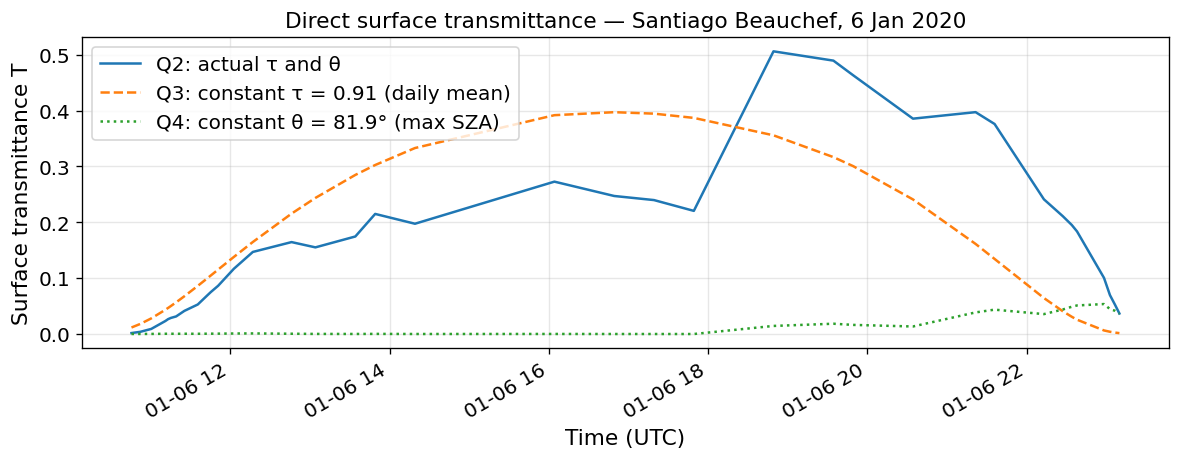

Spread of T (actual):      0.504
Spread of T (const tau):   0.396  <- effect of theta alone
Spread of T (const theta): 0.054  <- effect of tau alone


In [51]:
# Compute transmittance for all three scenarios, using beers law 
T_actual    = np.exp(-tau_obs  / mu_obs)     # Q2: real tau and real theta
T_const_tau = np.exp(-tau_mean / mu_obs)     # Q3: fix tau at mean, vary theta
T_const_sza = np.exp(-tau_obs  / mu_min)     # Q4: fix theta at max SZA, vary tau

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(time_obs, T_actual,    lw=1.5,        label="Q2: actual τ and θ")
ax.plot(time_obs, T_const_tau, lw=1.5, ls="--", label=f"Q3: constant τ = {tau_mean:.2f} (daily mean)")
ax.plot(time_obs, T_const_sza, lw=1.5, ls=":",  label=f"Q4: constant θ = {sza_max:.1f}° (max SZA)")
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Surface transmittance T")
ax.set_title("Direct surface transmittance — Santiago Beauchef, 6 Jan 2020")
ax.legend()
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig("figures/aeronet_transmittance.png", bbox_inches="tight")
plt.show()

# Print the spread of each scenario — bigger spread = bigger influence
print(f"Spread of T (actual):      {T_actual.max()-T_actual.min():.3f}")
print(f"Spread of T (const tau):   {T_const_tau.max()-T_const_tau.min():.3f}  <- effect of theta alone")
print(f"Spread of T (const theta): {T_const_sza.max()-T_const_sza.min():.3f}  <- effect of tau alone")

### Answers to Q2–Q5

**Q2 — How does the direct transmittance at the surface change throughout the day?**

Looking at the blue line, transmittance is low in the morning (before ~18:00 UTC). It peaks around 19:00–20:00 UTC when the sun close to its highest point. After that it decreases as the sun sets. Notably, AOD also decreases in the afternoon, so the drop in transmittance toward evening is slightly offset by cleaner air. But I would say it is pretty polluted throughout the whole day. 

**Q3 — For a constant τ (daily mean), how does transmittance change throughout the day?**

With AOD fixed at the daily mean, transmittance is driven entirely by  θ. It is lowest in the morning and evening when the sun is near the horizon (large SZA, long slant path), and highest at solar noon when the sun is directly overhead. This is because the path the photon has to take is smallest then. 

**Q4 — For a constant θ (daily maximum θ = 81.9°), how does transmittance change throughout the day?**

With SZA fixed at its maximum, transmittance stays near zero all day regardless of how much AOD changes, this is because at θ = 81.9°, the sun is basically set.


**Q5: Which Factor Dominates — τ or θ?**

The solar zenith angle,  θ is most responsible for the variance in transmittance thoughout theday. You can see this in graph where the orange dotted line represents a changing theta and keeping the optical depth constant creates more variance compated to the green line where changing the optical depth and keeping theta constant does not create much change. This is because it is pretty polluted throughout the day in Santiago, AOD is more constant than the sun. The AOD decreases at around the 18th hour UTC time, and only then do you see a slight increase in transmittance in the green line. 


---
## Part V: Student Investigation



Clearly state:
• the question and hypothesis
• the experiment performed
• the result

### Question

Given the time of day that AOD decreased, it looks like afternoon winds could have moved the pollution out of Santiago but what if it was the opposite and morning/afternoon winds brought in the pollution instead? Specifically if the AOD time series is reversed, how would transmittance vary, and which scenario would be sunnier?

### Hypothesis

If we integrate the total transmittance throughout the day, I think both scenarios would be pretty similar, given that the maximum AOD is around solar noon. Specifically, I think in the inverted AOD scenario there would be more transmittance in the morning than observed but less in the afternoon, so they would be roughly equal if we added up the transmittance throughout the day.

### Experiment

To calculate and compare transmittance, invert the AOD time series in the time dimension, then use Beer's Law to calculate transmittance of inverted AOD.

/var/folders/9t/9gfwlwbs0vxb1xc247fmxzk80000gn/T/ipykernel_4119/1084409752.py:15: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  T_int_observed = np.trapz(T_observed, time_hours)
/var/folders/9t/9gfwlwbs0vxb1xc247fmxzk80000gn/T/ipykernel_4119/1084409752.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  T_int_inverted  = np.trapz(T_inverted,  time_hours)


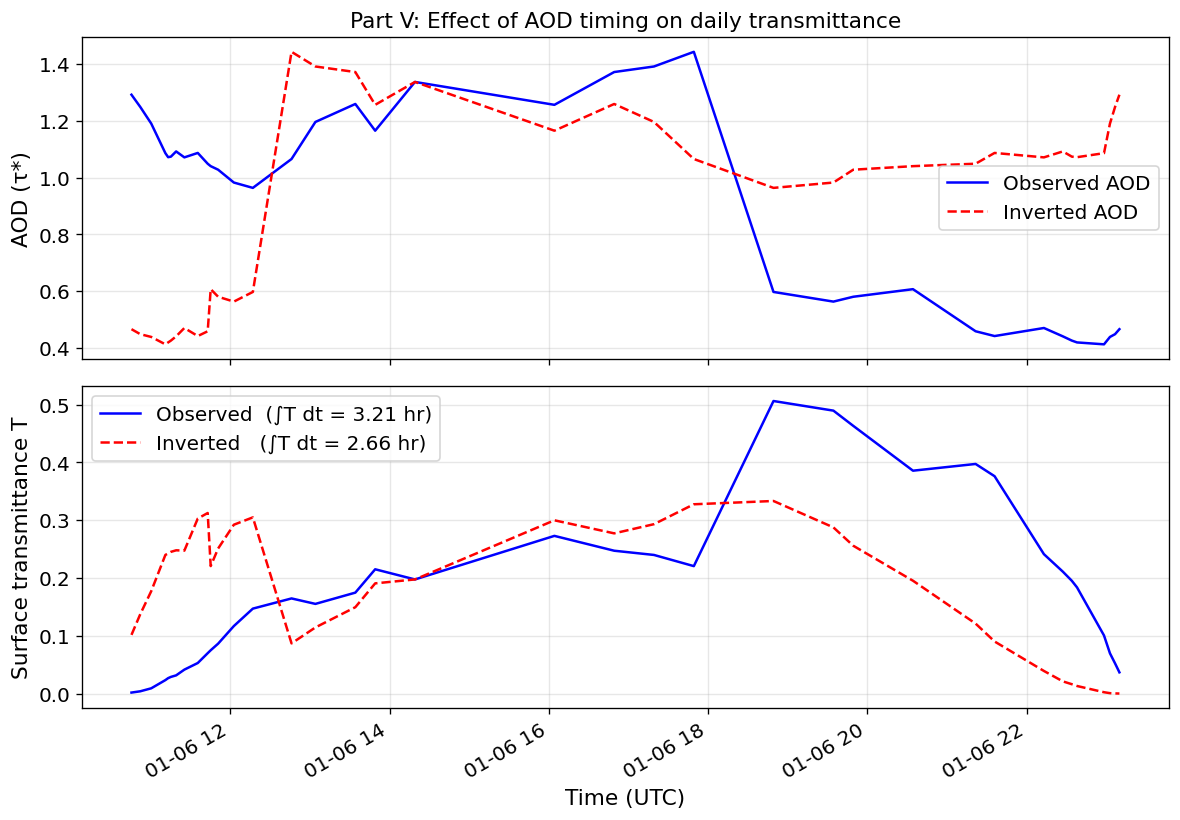

Integrated T (observed): 3.206 hr
Integrated T (inverted): 2.655 hr
Difference: -0.551 hr


In [ ]:
# --- Part V: Does timing of peak AOD matter for daily transmittance? ---

# Invert the AOD time series — peak AOD now occurs in afternoon
aod_observed = tau_obs          # cleaned numpy array (37 points, NaNs dropped)
aod_inverted  = tau_obs[::-1]   # same length — AOD peak shifted to afternoon

# Compute transmittance for both, keeping SZA identical
T_observed = np.exp(-aod_observed / mu_obs)
T_inverted  = np.exp(-aod_inverted  / mu_obs)

# Convert time to hours for integration
time_hours = (time_obs - time_obs.iloc[0]).dt.total_seconds() / 3600

# Integrate total transmittance over the day
T_int_observed = np.trapz(T_observed, time_hours)
T_int_inverted  = np.trapz(T_inverted,  time_hours)

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Top: AOD time series
axes[0].plot(time_obs, aod_observed, 'b-',  lw=1.5, label='Observed AOD')
axes[0].plot(time_obs, aod_inverted,  'r--', lw=1.5, label='Inverted AOD')
axes[0].set_ylabel('AOD (τ*)')
axes[0].set_title('Part V: Effect of AOD timing on daily transmittance')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bottom: resulting transmittance
axes[1].plot(time_obs, T_observed, 'b-',  lw=1.5, label=f'Observed  (∫T dt = {T_int_observed:.2f} hr)')
axes[1].plot(time_obs, T_inverted,  'r--', lw=1.5, label=f'Inverted   (∫T dt = {T_int_inverted:.2f} hr)')
axes[1].set_xlabel('Time (UTC)')
axes[1].set_ylabel('Transmittance (T)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.savefig('figures/partV_aod_timing.png', bbox_inches='tight')
plt.show()

print(f"Integrated T (observed): {T_int_observed:.3f} hr")
print(f"Integrated T (inverted): {T_int_inverted:.3f} hr")
print(f"Difference: {T_int_inverted - T_int_observed:.3f} hr")

### Results

**Observed (blue):** High AOD (~1.0–1.4) from 10:00–18:00 UTC (morning through solar noon), then AOD drops to ~0.4–0.6 after 18:00 UTC (local afternoon/evening).

**Inverted (red):** Flipped — low AOD in the morning, high AOD (~1.0–1.4) appearing  before solar noon and into the afternoon.

- The observed case gets its best transmittance (~0.5) around 19:00–20:00 UTC because the AOD has already dropped and the sun is still at a reasonable angle (SZA ~30–40°).
- The inverted case peaks at only ~0.30 because when AOD is low in the morning, but the sun is near the horizon (SZA ~80°), which limits transmittance regardless of the low AOD.
- Then when the sun is finally high enough around 17:00–19:00 UTC, the inverted case has high AOD blocking it.

When I integrated the transmittance, I got 3.206 hrs of full transmittance for the observed case and 2.655 hr for the inverted case  so they are actually a bit different. The observed case gets more total sunlight than the inverted case because the drop-off in AOD occurs when the sun is still fairly high in the sky.

**AI Usage Statement**  
Tool: Claude 
Prompt: Build Part I of HW1 — the Monte Carlo photon extinction model — in a Jupyter notebook following the assignment instructions.  
How it was used: Generated the initial notebook structure and Monte Carlo simulation code. 

I also used claude to make the transmittance_profile function, and I also went back and used claude to and make all the markdown cells and plots visually more appealing. 